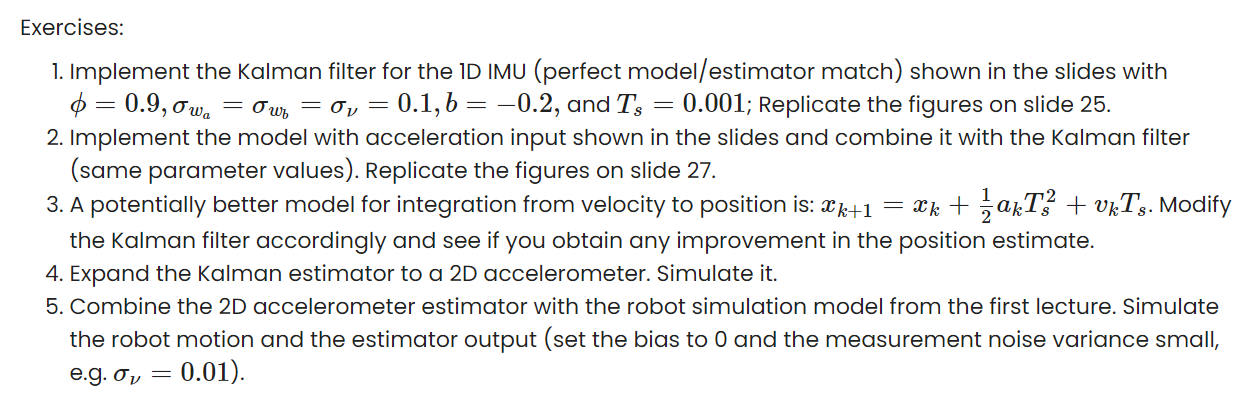

In [2]:
phi = 0.9
SD_a = 0.1
SD_b = 0.001
SD_v = 0.1
b = -0.2
Ts = 0.01

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import block_diag

rng = np.random.default_rng(42)
N   = 5000

## Task 1: 1D IMU KF — state [p, v, a, b]
Perfect model/estimator match. Replicate slide 25. (system)

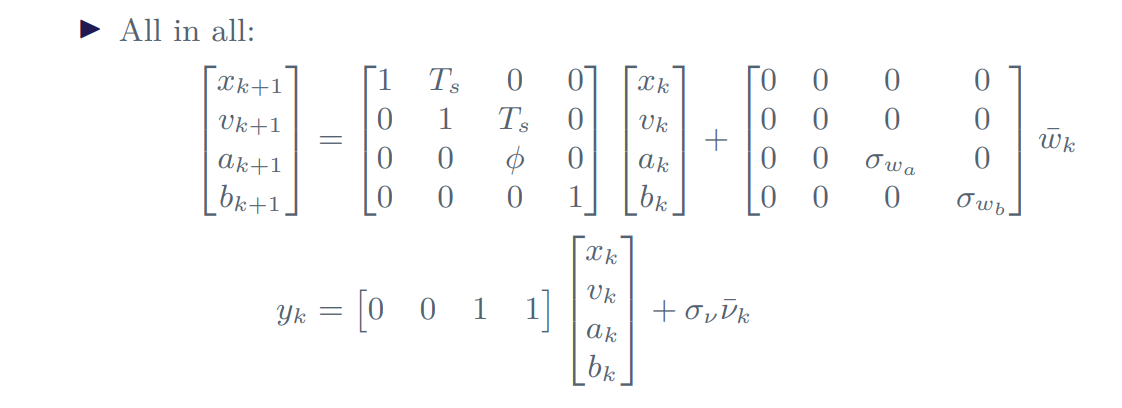

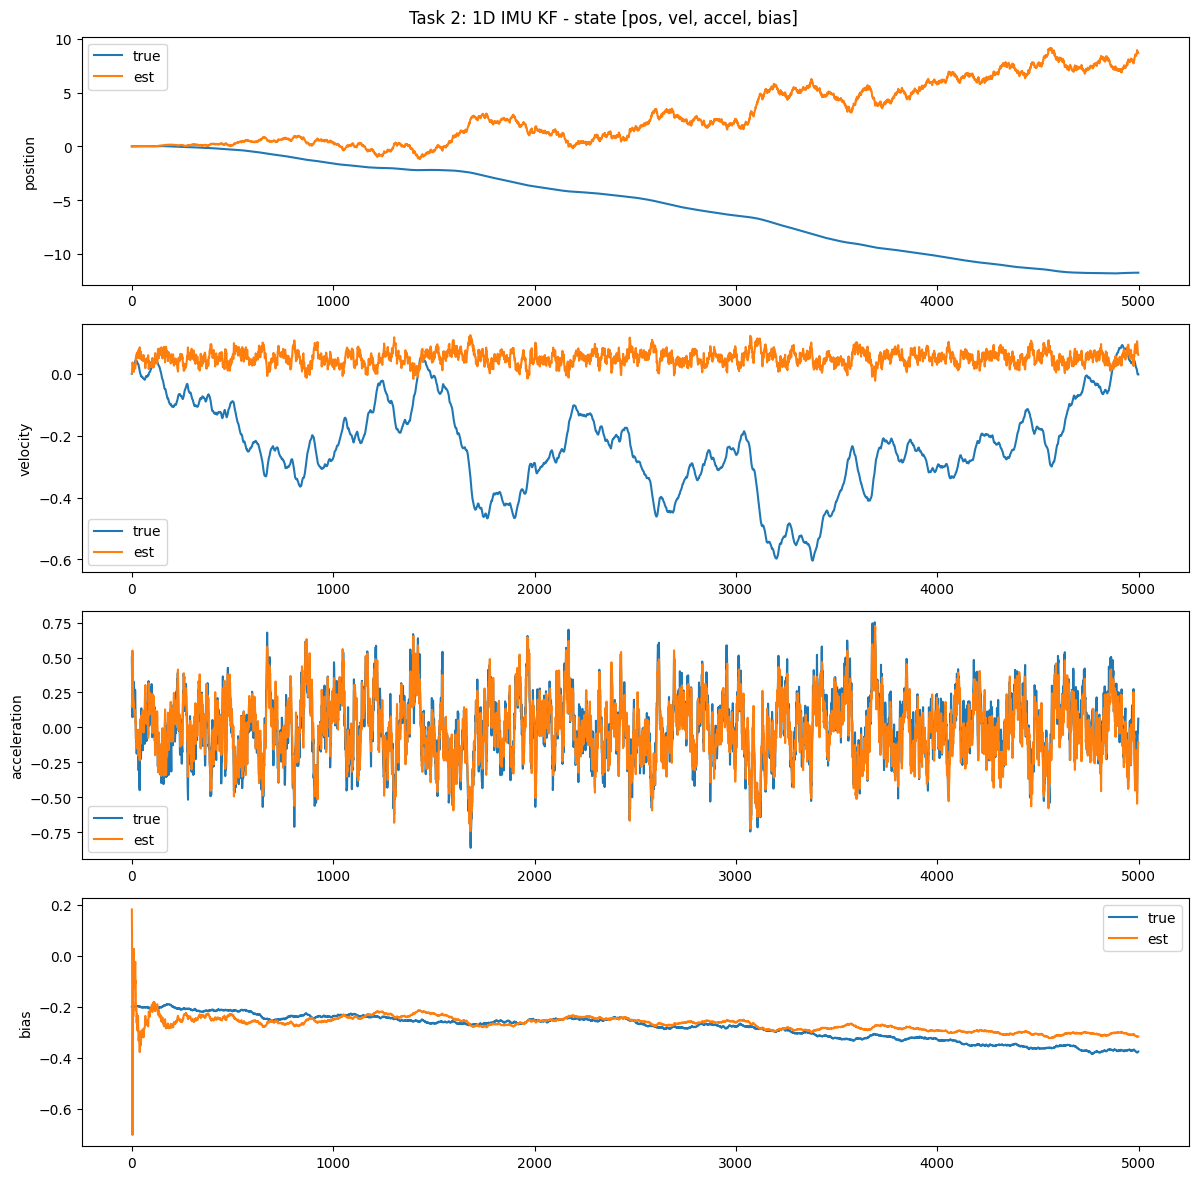

In [4]:
# Task 1: estimate acceleration and bias from noisy measurement
# state: [pos, vel, accel, bias]
# position integrates velocity, velocity integrates acceleration
# accel: AR(1) process
# bias:  random walk
# measurement: accel + bias + noise

Phi_2 = np.array([[1, Ts,  0,   0],
                   [0,  1, Ts,   0],
                   [0,  0, phi,  0],
                   [0,  0,  0,   1]])
Q_2 = np.diag([0.0, 0.0, SD_a**2, SD_b**2])
H_2 = np.array([[0, 0, 1, 1]])   # measures accel + bias
R_2 = np.array([[SD_v**2]])

state_true_2 = np.array([[0.0], [0.0], [0.5], [b]])
true_2 = np.zeros((4, N))
z_2    = np.zeros(N)

for k in range(N):
    true_2[:, k] = state_true_2[:, 0]
    z_2[k] = (H_2 @ state_true_2)[0, 0] + SD_v * rng.standard_normal()
    w = np.array([[0.0], [0.0],
                  [SD_a * rng.standard_normal()],
                  [SD_b * rng.standard_normal()]])
    state_true_2 = Phi_2 @ state_true_2 + w

state_est_2 = np.zeros((4, 1))
P_2 = np.eye(4)
est_2 = np.zeros((4, N))

for k in range(N):
    # predict
    state_est_2 = Phi_2 @ state_est_2
    P_2 = Phi_2 @ P_2 @ Phi_2.T + Q_2
    # update
    innov = z_2[k] - (H_2 @ state_est_2)[0, 0]
    S = H_2 @ P_2 @ H_2.T + R_2
    K = P_2 @ H_2.T @ np.linalg.inv(S)
    state_est_2 = state_est_2 + K * innov
    IKH = np.eye(4) - K @ H_2
    P_2 = IKH @ P_2 @ IKH.T + K @ R_2 @ K.T
    est_2[:, k] = state_est_2[:, 0]

fig, axes = plt.subplots(4, 1, figsize=(12, 12))
fig.suptitle("Task 2: 1D IMU KF - state [pos, vel, accel, bias]")
for i, label in enumerate(["position", "velocity", "acceleration", "bias"]):
    axes[i].plot(true_2[i], label="true"); axes[i].plot(est_2[i], label="est")
    axes[i].set_ylabel(label); axes[i].legend()
plt.tight_layout(); plt.show()

## Task 2: 1D IMU with position/velocity — state [x, v, a, b]
Acceleration input drives position. Replicate slide 27.

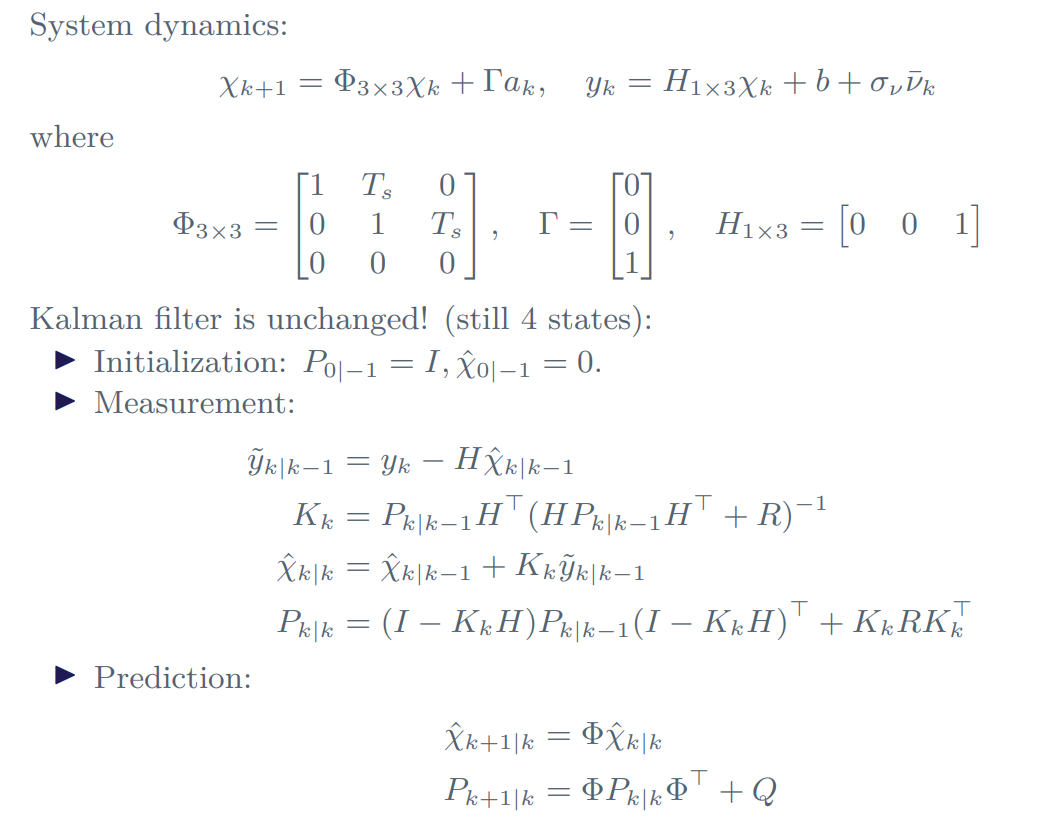

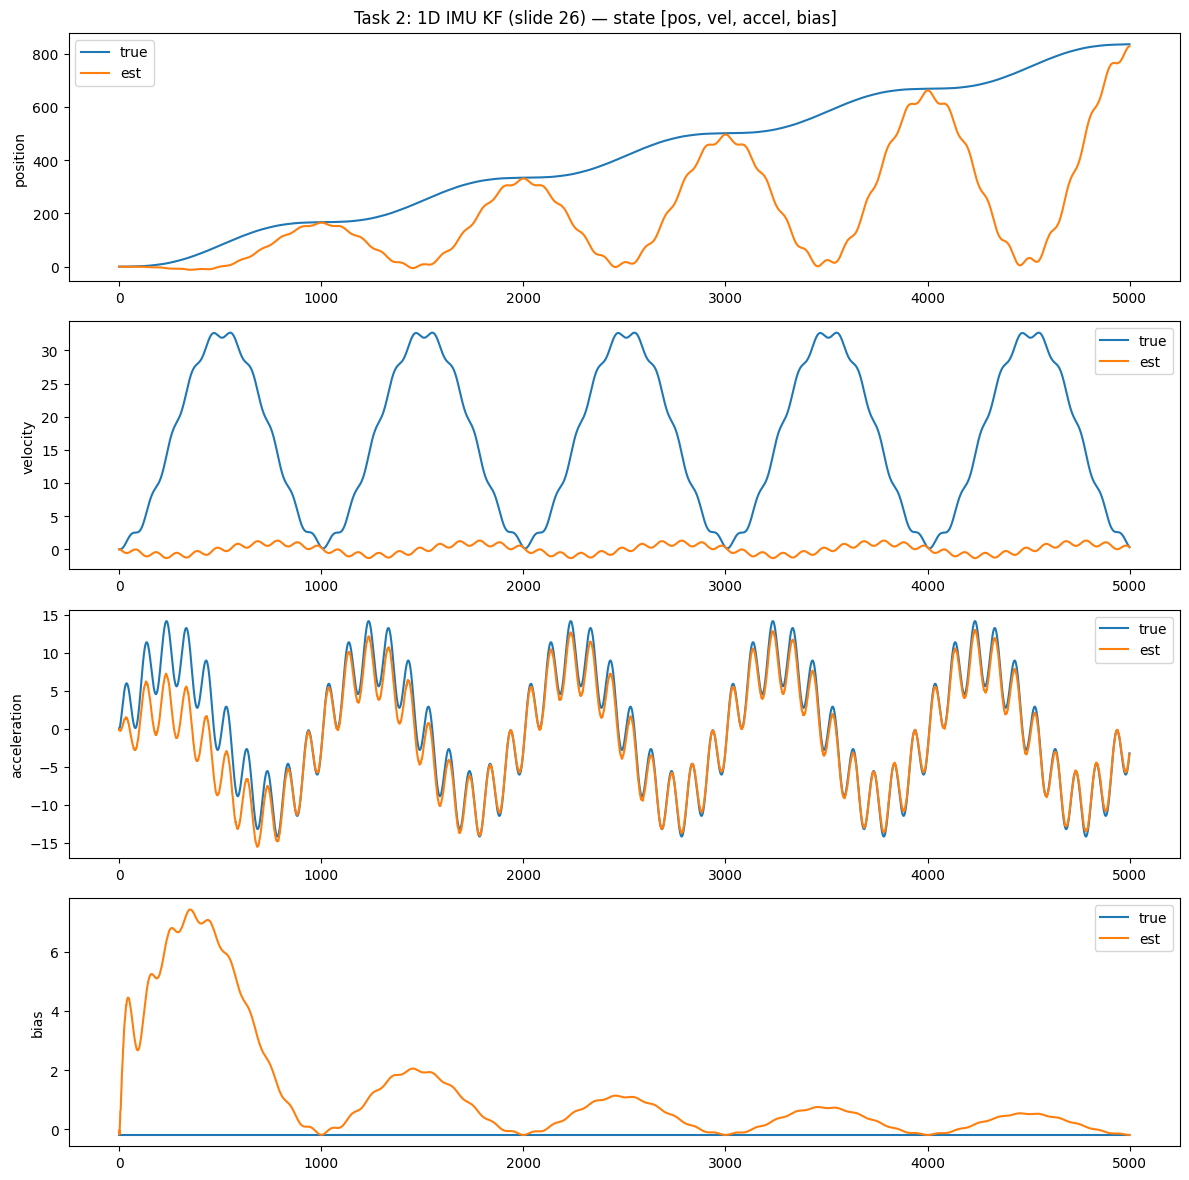

In [5]:
# Task 2 (slide 26): acceleration as external input via Gamma
# state: [pos, vel, accel, bias]
# Both true system and filter share the same Phi (Phi[2,2]=0, no AR(1) self-propagation)
# True system: accel state is driven by AR(1) input a_k (known to system, unknown to filter)
# Filter: uses acceleration_input=0 since it has no independent acceleration source

Phi_2   = np.array([[1, Ts, 0, 0],
                    [0,  1, Ts, 0],
                    [0,  0,  phi, 0],   # accel does not self-propagate
                    [0,  0,  0, 1]])
Gamma_2 = np.array([[0.0], [0.0], [1.0], [0.0]])   # a_k feeds directly into accel state

Q_2 = np.diag([0.0, 0.0, SD_a**2, 0])
H_2 = np.array([[0, 0, 1, 1]])   # measures accel + bias
R_2 = np.array([[SD_v**2]])

# --- generate external acceleration as AR(1): a_{k+1} = phi*a_k + w_a ---
true_accel_input = np.zeros(N)

# --- true system driven by true_accel_input via Gamma_2 ---
state_true_2 = np.array([[0.0], [0.0], [0], [b]])
true_2 = np.zeros((4, N))
z_2    = np.zeros(N)

for k in range(N):
    true_accel_input[k] = 0.5*np.sin(2*np.pi*Ts*k) + np.sin(2*np.pi*(Ts/10)*k) # example: sinusoidal acceleration input


for k in range(N):
    true_2[:, k] = state_true_2[:, 0]
    z_2[k] = (H_2 @ state_true_2)[0, 0] + SD_v * rng.standard_normal()
    # w_bias = np.array([[0.0], [0.0], [0.0], [SD_b * rng.standard_normal()]])
    state_true_2 = Phi_2 @ state_true_2 + Gamma_2 * true_accel_input[k]

# --- Kalman filter: a_k unknown to filter, so acceleration_input=0 ---
state_est_2 = np.zeros((4, 1))
P_2 = np.eye(4)
est_2 = np.zeros((4, N))

for k in range(N):
    state_est_2 = Phi_2 @ state_est_2
    P_2 = Phi_2 @ P_2 @ Phi_2.T + Q_2
    innov = z_2[k] - (H_2 @ state_est_2)[0, 0]
    S = H_2 @ P_2 @ H_2.T + R_2
    K = P_2 @ H_2.T @ np.linalg.inv(S)
    state_est_2 = state_est_2 + K * innov
    IKH = np.eye(4) - K @ H_2
    P_2 = IKH @ P_2 @ IKH.T + K @ R_2 @ K.T
    est_2[:, k] = state_est_2[:, 0]

fig, axes = plt.subplots(4, 1, figsize=(12, 12))
fig.suptitle("Task 2: 1D IMU KF (slide 26) — state [pos, vel, accel, bias]")
for i, label in enumerate(["position", "velocity", "acceleration", "bias"]):
    axes[i].plot(true_2[i], label="true"); axes[i].plot(est_2[i], label="est")
    axes[i].set_ylabel(label); axes[i].legend()
plt.tight_layout(); plt.show()

## Task 4: 2D accelerometer
Expand to state [x, vx, ax, bx, y, vy, ay, by].

  x   : RMSE=5.7407
  vx  : RMSE=0.3002
  ax  : RMSE=0.0958
  bx  : RMSE=0.0564
  y   : RMSE=6.7351
  vy  : RMSE=0.5105
  ay  : RMSE=0.0905
  by  : RMSE=0.0497


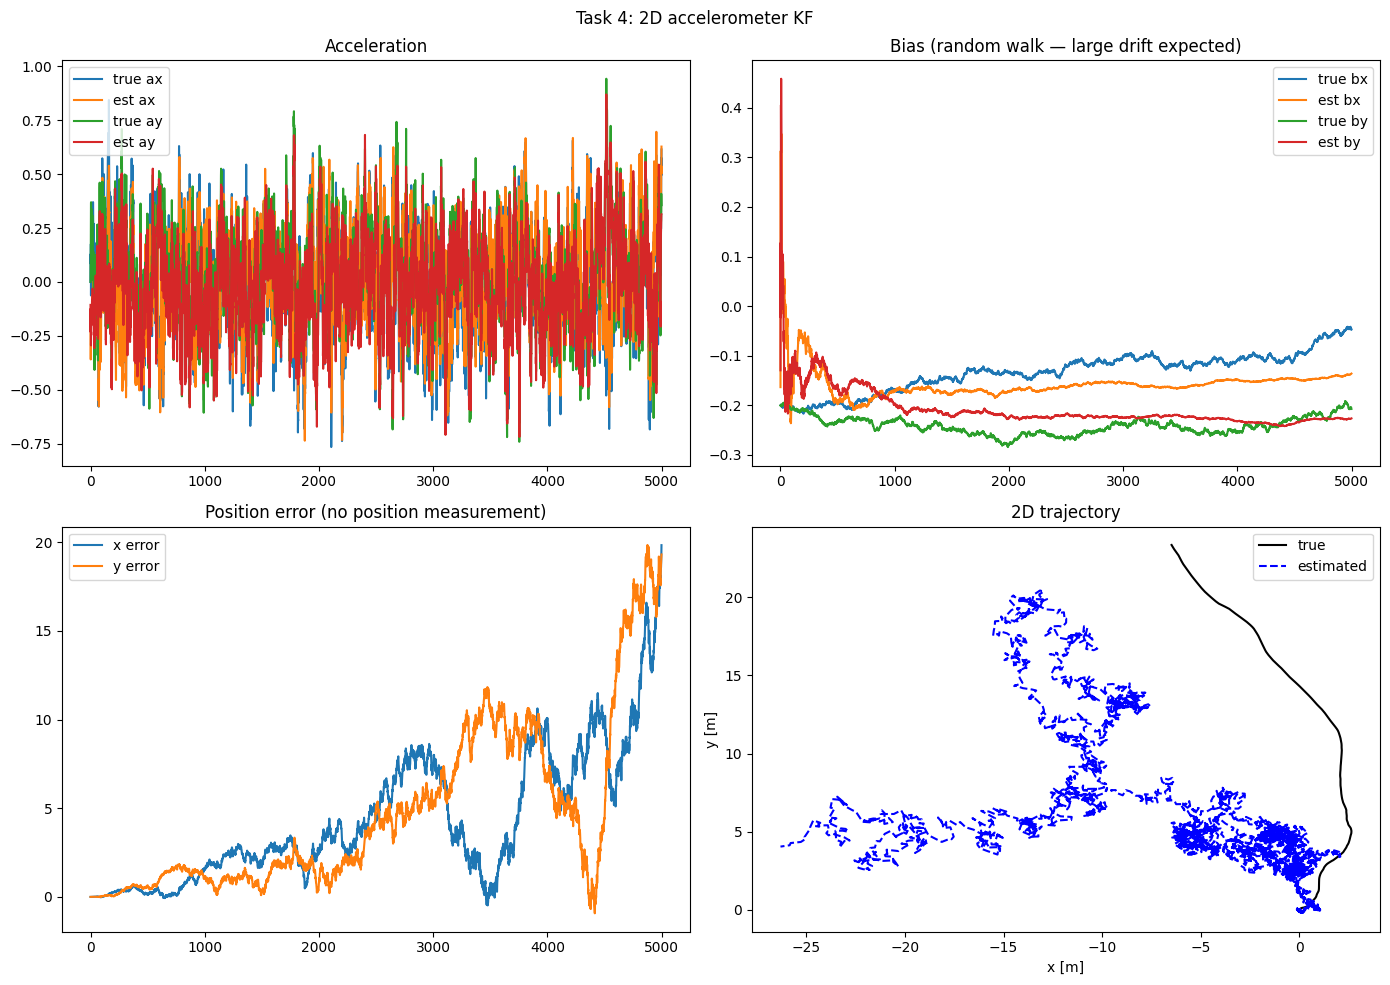

In [7]:
# Task 4: expand to 2D accelerometer
# state: [x, vx, ax, bx,  y, vy, ay, by]
# two measurements: x-accel+bias, y-accel+bias

Phi_4 = block_diag(Phi_3, Phi_3)
Q_4   = block_diag(Q_2, Q_2)
H_4   = np.zeros((2, 8))
H_4[0, 2] = 1; H_4[0, 3] = 1   # z_x = ax + bx
H_4[1, 6] = 1; H_4[1, 7] = 1   # z_y = ay + by
R_4 = np.diag([SD_v**2, SD_v**2])

rng4 = np.random.default_rng(123)
state_true_4 = np.array([[0.0], [0.0], [0], [b],
                           [0.0], [0.0], [0], [b]])
true_4 = np.zeros((8, N))
z_4    = np.zeros((2, N))

for k in range(N):
    true_4[:, k] = state_true_4[:, 0]
    z_4[:, k] = (H_4 @ state_true_4)[:, 0] + SD_v * rng4.standard_normal(2)
    w = np.zeros((8, 1))
    w[2, 0] = SD_a * rng4.standard_normal(); w[3, 0] = SD_b * rng4.standard_normal()
    w[6, 0] = SD_a * rng4.standard_normal(); w[7, 0] = SD_b * rng4.standard_normal()
    state_true_4 = Phi_4 @ state_true_4 + w

state_est_4 = np.zeros((8, 1))
P_4 = np.eye(8)
est_4 = np.zeros((8, N))

for k in range(N):
    # predict
    state_est_4 = Phi_4 @ state_est_4
    P_4 = Phi_4 @ P_4 @ Phi_4.T + Q_4
    # update
    innov = z_4[:, k:k+1] - H_4 @ state_est_4
    S = H_4 @ P_4 @ H_4.T + R_4
    K = P_4 @ H_4.T @ np.linalg.inv(S)
    state_est_4 = state_est_4 + K @ innov
    IKH = np.eye(8) - K @ H_4
    P_4 = IKH @ P_4 @ IKH.T + K @ R_4 @ K.T
    est_4[:, k] = state_est_4[:, 0]

k_axis = np.arange(N)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Task 4: 2D accelerometer KF")

axes[0, 0].plot(k_axis, true_4[2], label="true ax"); axes[0, 0].plot(k_axis, est_4[2], label="est ax")
axes[0, 0].plot(k_axis, true_4[6], label="true ay"); axes[0, 0].plot(k_axis, est_4[6], label="est ay")
axes[0, 0].set_title("Acceleration"); axes[0, 0].legend()

axes[0, 1].plot(k_axis, true_4[3], label="true bx"); axes[0, 1].plot(k_axis, est_4[3], label="est bx")
axes[0, 1].plot(k_axis, true_4[7], label="true by"); axes[0, 1].plot(k_axis, est_4[7], label="est by")
axes[0, 1].set_title("Bias (random walk — large drift expected)"); axes[0, 1].legend()

axes[1, 0].plot(k_axis, true_4[0] - est_4[0], label="x error")
axes[1, 0].plot(k_axis, true_4[4] - est_4[4], label="y error")
axes[1, 0].set_title("Position error (no position measurement)"); axes[1, 0].legend()

axes[1, 1].plot(true_4[0], true_4[4], "k-", label="true")
axes[1, 1].plot(est_4[0], est_4[4], "b--", label="estimated")
axes[1, 1].set_title("2D trajectory"); axes[1, 1].set_xlabel("x [m]"); axes[1, 1].set_ylabel("y [m]")
axes[1, 1].legend()

for i, name in enumerate(["x","vx","ax","bx","y","vy","ay","by"]):
    print(f"  {name:4s}: RMSE={np.sqrt(np.mean((true_4[i]-est_4[i])**2)):.4f}")

plt.tight_layout(); plt.show()